In [1]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import anndata as ad
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import gaussian_kde

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
indir = './'
outdir = './plots'

In [ ]:
from matplotlib.font_manager import fontManager, FontProperties
font_path = "/arial/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()

In [ ]:
state="hyper"

subclass_list = pd.read_csv('../../../03.data/04.config_files/subclass_order.csv', header=None)[0].to_list()
subclass_list=[i for i in subclass_list if "NN" not in i]

df_RNA=pd.read_csv('../../03.Joint-Cabernet.cellType_State/04-Correlation_calculation/all_cell_correlation/02-our_subclass_mean_dat_final.csv',index_col=0).T.loc[subclass_list,:]

df_frac_segment_subclass=dict()
df_frac_segment_subclass["5hmCG"]=ad.read_h5ad('../../04.subclass.DMR/04-summarize_RankSumTest/00-merged_allc_mcds/5hmC_merged_allc_with_5hmC_segment.h5ad').to_df().iloc[:len(subclass_list),:]
df_frac_segment_subclass["5hmCG"].index=df_RNA.index

DMR_states_df=ad.read_h5ad('../../04.subclass.DMR/03-stratified_RankSumTest_1vsOthers/01_subclasses_in_neuron_1vsOthers/5hmCG_DMR_states_neuron_1vsOthers.h5ad').to_df()

if state == "hyper":
    segment_differential_states=(DMR_states_df==1).sum(axis=0)
elif state == "hypo":
    segment_differential_states=(DMR_states_df==-1).sum(axis=0)
elif state == "all":
    segment_differential_states=(DMR_states_df.abs()==1).sum(axis=0)

differential_segments=segment_differential_states[segment_differential_states>0].index

def get_midpoint_bin(segment_):
    chrom_, start_, end_ = segment_.split("_")
    return int((int(end_)+int(start_)-1)/2/10_000)                        

differential_segments_by_chrom={chrom_ : [(i, get_midpoint_bin(i)) for i in differential_segments if i.split("_")[0]==chrom_] for chrom_ in ["chr"+str(j) for j in range(1,20)]}

In [ ]:
genes_df = pd.read_csv('../../../03.data/01.ref/mm10.genes.bed', sep='\t', header=None, names=['chromosome', 'start', 'end', 'gene_id', 'gene_name', 'gene_type', 'strand'])

In [6]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import cooltools
import cooler

import datetime

from matplotlib.colors import LogNorm

In [ ]:
csv_path = "../../../03.data/02.metainfo/01.Young_Mouse/subclass_name.Joint_Cabernet_corresponding_to_3C.csv"
df = pd.read_csv(csv_path, sep=',')
df = df.iloc[:len(subclass_list),:]

In [8]:
# Etl4 has been selected based on 'selected_loops.csv' and visual examination.
genes_df[genes_df['gene_name']=='Etl4']

,chromosome,start,end,gene_id,gene_name,strand
3829,chr2,19909780,20810713,ENSMUSG00000036617.16,Etl4,+


In [17]:
gene_id_ = 'ENSMUSG00000036617.16'

In [ ]:
# load the 3C data
print(f"initialization started  at {datetime.datetime.now()}")
resolution_=10_000

mcool_file={subclass_liu : f'{subclass_liu}.Q.10K.mcool'
           for subclass_liu in df['subclass_liu']}
clr={subclass_Nature : cooler.Cooler(f'{mcool_file[subclass_Nature]}::resolutions/{resolution_}') for subclass_Nature in df['subclass_liu']}
matrixes_={
    chrom_ : 
           [
               clr[subclass_Nature].matrix(balance=True).fetch(chrom_)[:] 
                     for subclass_Nature in df['subclass_liu']
           ] 
           for chrom_ in ["chr"+str(i) for i in [2] ] # only relevant chromosomes are loaded
}
print(f"initialization finished at {datetime.datetime.now()}")

initialization started  at 2025-11-20 16:44:37.335804
initialization finished at 2025-11-20 16:47:25.903430


In [10]:
from cooltools.lib.numutils import interp_nan

In [11]:
from scipy.stats import linregress

In [12]:
df_chrom30k_step10k = ad.read_h5ad(f'{indir}/5hmCG_frac_chrom30k_step10k_by_subclass/5hmCG_frac_chrom30k_step10k_by_subclass.h5ad').to_df().iloc[:len(subclass_list),]

In [13]:
chrom_ = 'chr2'

In [ ]:
df_RNA=pd.read_csv('../../03.Joint-Cabernet.cellType_State/04-Correlation_calculation/all_cell_correlation/02-our_subclass_mean_dat_final.csv',index_col=0).T.loc[subclass_list,:]
max_threshold_=0.2
cv_threshold_=0.4
df_RNA_selected=df_RNA.loc[subclass_list,:]
df_RNA_selected=df_RNA_selected.loc[subclass_list,
    (df_RNA_selected.max(axis=0)>max_threshold_) &
    (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)
            ]
df_RNA_selected.shape

/tmp/ipykernel_19399/3988717466.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)


(26, 1928)

Text(0, 0.5, '3C interaction or RNA expression')

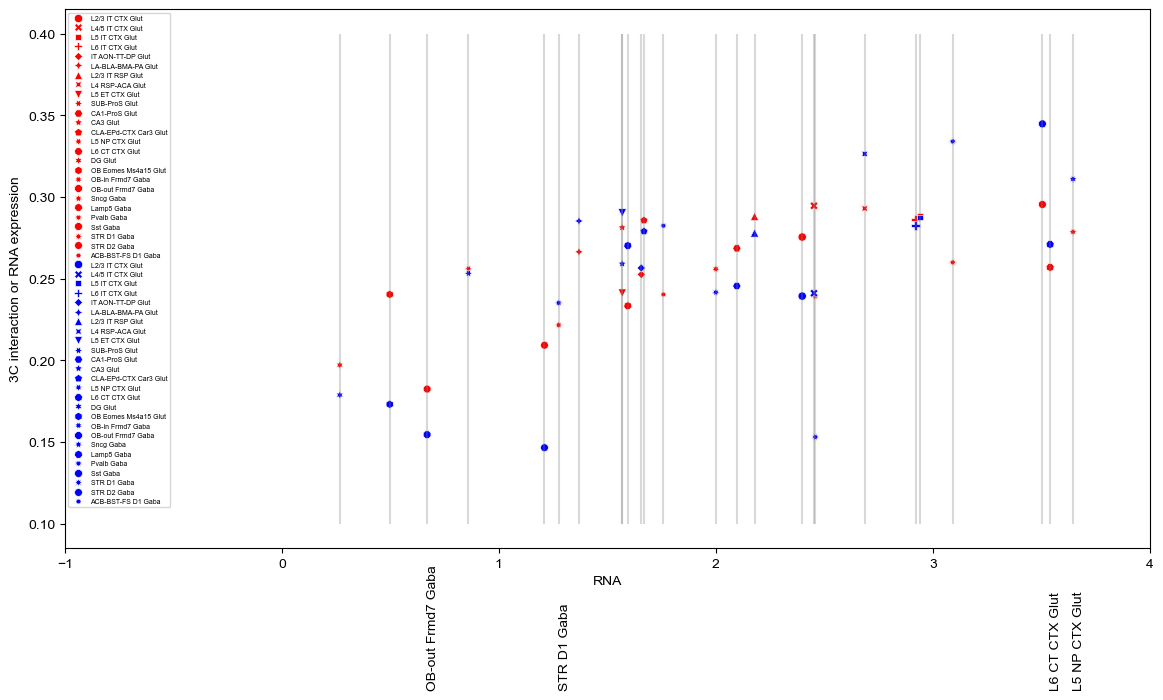

In [29]:
a=pd.DataFrame(df_chrom30k_step10k.loc[:, [f'{chrom_}_{(i-1)*10_000}_{(i+2)*10_000}' for i in [1970,1973]]].mean(axis=1))
b=df_RNA_selected[[gene_id_]]
a.index=b.index
a.columns=['5hmCG']
b.columns=['RNA']
c=pd.concat([a,b], axis=1)
e=pd.DataFrame([np.nansum(matrixes_[chrom_][subclass_index]\
                       [1969: 1975, 1990:2082]) for subclass_index in range(len(subclass_list))])
b=df_RNA_selected[[gene_id_]]
e.index=b.index
e.columns=['3C interaction']
b.columns=['RNA']
f=pd.concat([e,b], axis=1)
plt.figure(figsize=(14,7))
sns.scatterplot(x=f['RNA'],y=f['3C interaction']/7.5,color='red',style=f.index)
sns.scatterplot(x=c['RNA'],y=c['5hmCG'],color='blue',style=c.index)
plt.vlines(c['RNA'],0.1,0.4, color='grey', alpha=0.3)
for subclass_, (x, y) in c.iterrows():
    if subclass_ not in ['OB-out Frmd7 Gaba', 'STR D1 Gaba', 'L6 CT CTX Glut', 'L5 NP CTX Glut']:
        continue
    plt.text((y+0.),0,subclass_,rotation=90)
plt.xlim((-1,4))
plt.legend(fontsize=5)
plt.ylabel('3C interaction or RNA expression')

<Figure size 177.165x177.165 with 0 Axes>

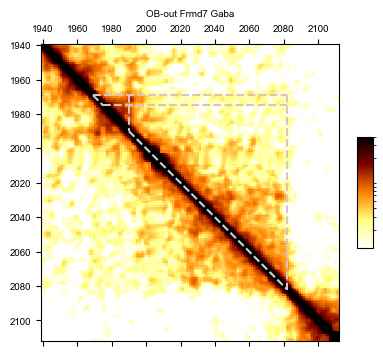

<Figure size 177.165x177.165 with 0 Axes>

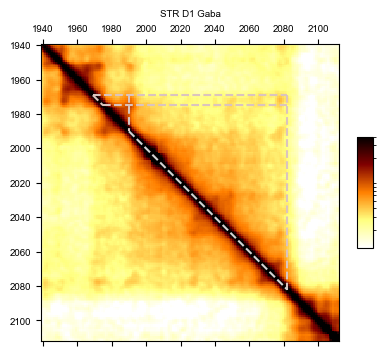

<Figure size 177.165x177.165 with 0 Axes>

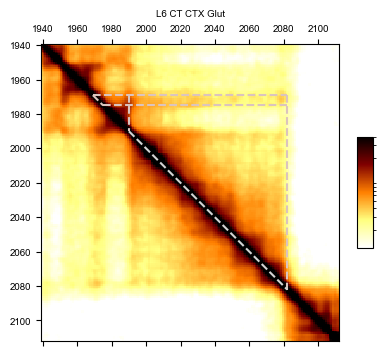

<Figure size 177.165x177.165 with 0 Axes>

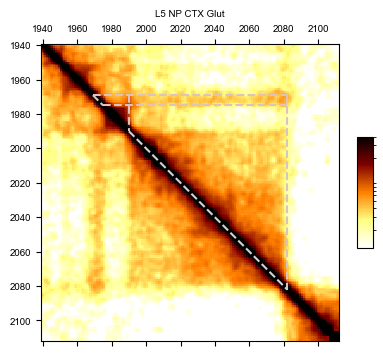

In [30]:
gene_name_ = 'Etl4'
gene_ = genes_df[genes_df["gene_name"]==gene_name_]
chrom_, gene_start_, gene_end_, strand_ = gene_.loc[:,["chromosome","start","end","strand"]].iloc[0,:]
gene_start_, gene_end_ = map(int, (gene_start_, gene_end_))
(TSS_, TES_) =(gene_start_, gene_end_)[::(2*(strand_=='+')-1)]
plot_lower_bin=1969-30
plot_upper_bin=2082+30
# plt.matshow works like range(start_, end_). The upper bin itself will not be shown, its start is the right border.
distal_lower, distal_upper, gene_lower, gene_upper = 1969, 1975, 1990, 2082

cmap_ = 'afmhot_r'
for subclass_ in ['OB-out Frmd7 Gaba', 'STR D1 Gaba', 'L6 CT CTX Glut', 'L5 NP CTX Glut']:
    plt.figure(figsize=(45/25.4, 45/25.4))
    plt.matshow(interp_nan(matrixes_[chrom_][subclass_list.index(subclass_)]\
                   [plot_lower_bin : plot_upper_bin, plot_lower_bin : plot_upper_bin]),
                   extent=[plot_lower_bin , plot_upper_bin , plot_upper_bin, plot_lower_bin],
                   norm=LogNorm(vmax=0.04, vmin=0.0011), cmap=cmap_)
    cb = plt.colorbar(shrink=0.3, aspect=7,ticks=[])
    color_for_guide_line='#DBC4BE'
    plt.hlines([distal_lower], distal_lower , gene_upper, color=color_for_guide_line, linestyles='dashed')
    plt.hlines([distal_upper], distal_upper , gene_upper, color=color_for_guide_line, linestyles='dashed')
    plt.vlines([gene_lower], distal_lower , gene_lower, color=color_for_guide_line, linestyles='dashed')
    plt.vlines([gene_upper], distal_lower , gene_upper, color=color_for_guide_line, linestyles='dashed')
    plt.plot((distal_lower, distal_upper), (distal_lower, distal_upper), color=color_for_guide_line, linestyle='dashed')
    plt.plot((gene_lower, gene_upper), (gene_lower, gene_upper), color='lightgrey', linestyle='dashed')
    plt.title(f'{subclass_}', fontdict={'size':7});
    plt.xticks(fontsize=7); plt.yticks(fontsize=7)
    plt.savefig(f'{outdir}/plot_Etl4-{cmap_}-{subclass_}.pdf')
    plt.savefig(f'{outdir}/plot_Etl4-{cmap_}-{subclass_}.png', dpi=600)
    plt.show()